# SHAP으로 분류 모델의 판단 읽기

**오늘의 질문: 모델은 어떤 정보를 보고 생존자를 사망으로 예측했을까요?**

[분류 모델의 평가지표](1.%20classification.ipynb)에서 사용한 초기 모델을 다시 만들고, SHAP으로 전체 경향과 승객 한 명의 판단을 읽습니다. 이어서 어린이 여부를 추가한 실험을 다시 살펴봅니다.

앞부분은 **함께 진행**, 마지막은 관심 예측과 분석 방법을 고르는 **직접 탐색**입니다. 이 노트북만 위에서부터 실행하면 됩니다.

## 1. 함께 진행 — 초기 모델 준비

데이터의 한 행은 타이타닉 승객 한 명입니다. 정답 `Survived`는 사망 0, 생존 1입니다.

| 입력 항목 | 의미·단위 |
|---|---|
| Pclass | 객실 등급: 1·2·3등급 |
| Sex | 성별: 모델 입력은 남성 0, 여성 1 |
| Age | 나이(세) |
| SibSp | 함께 탄 형제자매·배우자 수(명) |
| Parch | 함께 탄 부모·자녀 수(명) |
| Fare | 운임(파운드) |
| Embarked | 탑승 항구: S=1, C=2, Q=3 |

기존 모델과 비교하기 위해 입력 방식도 유지합니다.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import shap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from IPython.display import display

# 바꿔 볼 설정을 앞에 모읍니다.
random_state = 42
threshold = 0.5
child_age = 12
selected_passenger_id = None  # None이면 놓친 남성 어린이 중 PassengerId가 가장 작은 승객
data_path = Path("Titanic-Dataset.csv")
if not data_path.exists():
    data_path = Path("4. 분류/Titanic-Dataset.csv")

available_fonts = {f.name for f in fm.fontManager.ttflist}
korean_font = next((f for f in ["Malgun Gothic", "NanumGothic", "AppleGothic"] if f in available_fonts), None)
if korean_font:
    plt.rcParams["font.family"] = [korean_font, "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv(data_path)
y = df["Survived"]
X = df.drop(columns=["Survived", "PassengerId", "Name", "Ticket", "Cabin"]).copy()
X["Sex"] = X["Sex"].map({"male": 0, "female": 1})
X["Embarked"] = X["Embarked"].map({"S": 1, "C": 2, "Q": 3})
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=random_state
)
display(pd.DataFrame({"학습 결측(명)": X_train_raw.isna().sum(),
                      "평가 결측(명)": X_test_raw.isna().sum()}))
display(df.loc[X.index[X.isna().any(axis=1)], ["PassengerId", "Age", "Embarked"]].head())

C:\Users\rando\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,학습 결측(명),평가 결측(명)
Pclass,0,0
Sex,0,0
Age,137,40
SibSp,0,0
Parch,0,0
Fare,0,0
Embarked,2,0


,PassengerId,Age,Embarked
5,6,NaN,Q
17,18,NaN,S
19,20,NaN,C
26,27,NaN,C
28,29,NaN,Q


모델 입력에서 비어 있는 나이와 항구를 확인했습니다. 나이는 **학습 자료의 중앙값**, 항구는 **학습 자료에서 가장 많은 값**으로 채웁니다. 평가 자료에도 같은 값을 사용합니다. 원본과 채우기 전 입력은 따로 보관합니다.

,채울 값
Age,28.5
Embarked,1.0


채우기 전           채운 후         
      Age Embarked   Age Embarked
241   NaN      3.0  28.5      3.0
126   NaN      3.0  28.5      3.0
485   NaN      1.0  28.5      1.0
511   NaN      1.0  28.5      1.0
87    NaN      1.0  28.5      1.0

,초기 모델
정확도,0.804
정밀도,0.793
재현율,0.667
F1,0.724


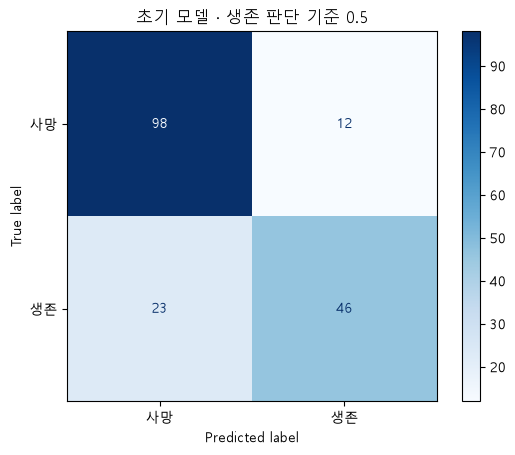

In [2]:
fill_values = {"Age": X_train_raw["Age"].median(), "Embarked": X_train_raw["Embarked"].mode()[0]}
X_train = X_train_raw.fillna(fill_values)
X_test = X_test_raw.fillna(fill_values)
display(pd.DataFrame({"채울 값": pd.Series(fill_values)}))
missing_rows = X_test_raw.index[X_test_raw.isna().any(axis=1)][:5]
display(pd.concat({"채우기 전": X_test_raw.loc[missing_rows, ["Age", "Embarked"]],
                   "채운 후": X_test.loc[missing_rows, ["Age", "Embarked"]]}, axis=1))

model = LogisticRegression(random_state=random_state, max_iter=1000)
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= threshold).astype(int)

def metrics(prediction):
    return {"정확도": accuracy_score(y_test, prediction),
            "정밀도": precision_score(y_test, prediction, zero_division=0),
            "재현율": recall_score(y_test, prediction, zero_division=0),
            "F1": f1_score(y_test, prediction, zero_division=0)}

display(pd.DataFrame({"초기 모델": metrics(y_pred)}).round(3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["사망", "생존"], cmap="Blues")
plt.title(f"초기 모델 · 생존 판단 기준 {threshold}")
plt.show()

혼동행렬의 가로축은 예측, 세로축은 실제 값이고 숫자는 사람 수(명)입니다. 실제 생존자를 사망으로 예측한 칸을 찾아보세요. 이제 어떤 입력이 이러한 판단에 기여했는지 살펴봅니다.

## 2. 전체 예측에서 무엇을 보고 있나?

SHAP은 기준 예측에서 각 항목이 예측을 얼마나 움직였는지 나누어 보여줍니다. **모델의 판단에 대한 설명이며 실제 생존·사망의 원인은 아닙니다.** 기준을 만들 때는 학습 자료만 사용하고, 평가 승객의 예측을 설명합니다.

- 아래 그래프의 점 하나는 해당 항목에 대한 승객 한 명의 기여도입니다. 세로로 퍼진 점은 겹침을 줄인 표시입니다.
- 가로축의 0보다 오른쪽은 생존 예측을 높이는 방향, 왼쪽은 낮추는 방향입니다.
- 색은 입력값의 크기입니다. 빨강은 큰 값, 파랑은 작은 값입니다. 성별은 여성=1이 빨강이며, 항구의 색은 숫자로 바꾼 항구 코드입니다.
- 위쪽 항목일수록 이 평가 자료에서 평균적인 기여의 크기가 큽니다. 중요하다는 이유만으로 오류 원인이라고 단정하지 않습니다.

가로축의 단위는 **로그 오즈**라는 모델 점수입니다. 확률의 %p가 아니므로, 승객별 생존 예측 확률은 별도 표에서 확인합니다.

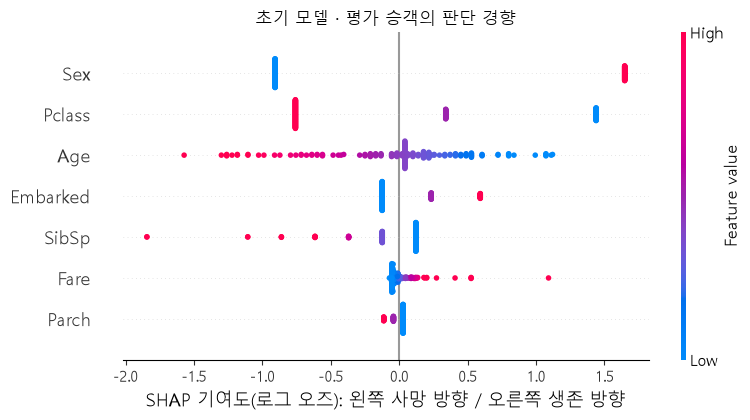

In [3]:
# 모든 학습 승객을 동일한 기준 자료로 사용합니다.
background = shap.maskers.Independent(X_train, max_samples=len(X_train))
explainer = shap.LinearExplainer(model, background)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values, max_display=len(X_test.columns), show=False)
plt.xlabel("SHAP 기여도(로그 오즈): 왼쪽 사망 방향 / 오른쪽 생존 방향")
plt.title("초기 모델 · 평가 승객의 판단 경향")
plt.tight_layout()
plt.show()

전체 그래프에서는 성별·객실 등급·나이가 예측에 크게 기여했습니다. 이제 실제로 틀린 예측 한 건에서 이 항목들이 어떻게 작용했는지 보겠습니다.

## 3. 생존한 아이를 왜 사망으로 예측했을까?

앞의 분류 분석에서는 12세 미만 남성 생존자 5명 중 4명을 놓쳤습니다. **그중 한 명의 정보를 먼저 보고, 모델의 판단을 따라가겠습니다.**

아래 표의 한 행은 승객 한 명입니다. 기본 예시는 놓친 남성 어린이 중 번호가 가장 작은 166번 승객입니다. 상단의 `selected_passenger_id`를 바꾸면 다른 평가 승객도 볼 수 있습니다.

In [4]:
results = df.loc[X_test.index, ["PassengerId", "Sex", "Pclass", "Age", "Fare", "SibSp", "Parch"]].copy()
results["실제"] = y_test
results["예측"] = y_pred
results["생존 예측 확률"] = y_proba
results["예측 결과"] = np.select([(y_test == 1) & (y_pred == 1), (y_test == 1) & (y_pred == 0), (y_test == 0) & (y_pred == 1)], ["생존으로 맞춤", "사망으로 놓침", "생존으로 오판"], default="사망으로 맞춤")

candidate_mask = (results["실제"] == 1) & (results["예측"] == 0) & (results["Sex"] == "male") & (results["Age"] < child_age)
candidates = results.loc[candidate_mask].sort_values("PassengerId")
if selected_passenger_id is None:
    if candidates.empty:
        raise ValueError("현재 설정에는 놓친 남성 어린이가 없습니다. results에서 평가 승객 번호를 골라 주세요.")
    selected_passenger_id = int(candidates.iloc[0]["PassengerId"])
selected_rows = results.index[results["PassengerId"] == selected_passenger_id]
if len(selected_rows) != 1:
    raise ValueError("selected_passenger_id는 위 평가 자료에 있는 PassengerId로 지정하세요.")
selected_index = selected_rows[0]
selected_position = X_test.index.get_loc(selected_index)
display(results.loc[[selected_index], ["PassengerId", "Sex", "Age", "Pclass"]].rename(
    columns={"PassengerId": "승객 번호", "Sex": "성별", "Age": "나이(세)", "Pclass": "객실 등급"}))
display(pd.DataFrame({
    "실제 결과": ["생존" if y_test.loc[selected_index] == 1 else "사망"],
    "모델 예측": ["생존" if y_pred[selected_position] == 1 else "사망"],
    "생존 예측 확률(%)": [round(y_proba[selected_position] * 100, 2)]
}))

,승객 번호,성별,나이(세),객실 등급
165,166,male,9.0,3


,실제 결과,모델 예측,생존 예측 확률(%)
0,생존,사망,15.95


기본 예시의 166번 승객은 **9세 남성, 3등급 객실 승객이며 실제로 생존했습니다.** 하지만 모델의 생존 예측 확률은 **15.95%**여서 사망으로 예측했습니다.

**모델은 이 아이의 어떤 정보를 생존 쪽으로, 어떤 정보를 사망 쪽으로 반영했을까요?** 아래 SHAP 그래프로 확인합니다.

- 한 줄은 이 승객의 입력 항목입니다. 왼쪽의 `9 = Age`는 모델에 나이 9세가 들어갔다는 뜻입니다.
- 빨간 화살표는 생존 예측을 높이고, 파란 화살표는 낮추는 방향입니다. 길수록 기여가 큽니다.
- 먼저 **Age, Sex, Pclass 세 줄의 방향과 크기**를 봅니다.

가로축은 앞에서 본 모델 점수(로그 오즈)이며 확률의 %p가 아닙니다. 아래쪽 시작 점수 `E[f(X)]`에 각 기여를 합치면 위쪽 최종 점수 `f(x)`가 됩니다. SHAP은 모델의 판단을 설명합니다.

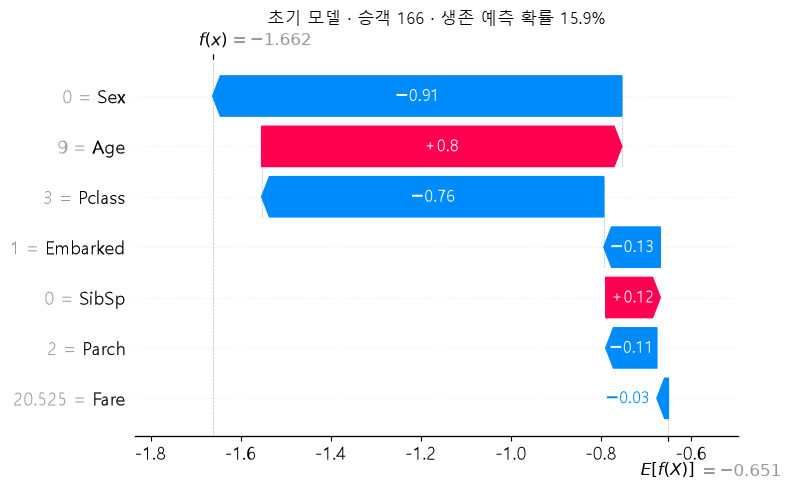

In [5]:
shap_table = pd.DataFrame(shap_values.values, index=X_test.index, columns=X_test.columns)
shap.plots.waterfall(shap_values[selected_position], max_display=len(X_test.columns), show=False)
plt.title(f"초기 모델 · 승객 {selected_passenger_id} · 생존 예측 확률 {y_proba[selected_position]:.1%}")
plt.tight_layout()
plt.show()

**166번 승객의 그래프를 읽으면:**

- 9세라는 나이는 생존 방향으로 작용했습니다.
- 남성이라는 정보와 3등급 객실이라는 정보는 사망 방향으로 작용했습니다.
- 다른 항목까지 합친 결과, 모델은 생존 가능성을 낮게 계산했습니다.

즉, **나이를 반영하지 않은 것은 아닙니다. 나이가 생존 쪽으로 작용해도 최종 예측은 사망이었습니다.** 한 사람의 설명이므로 다른 승객도 모두 같다고 볼 수는 없습니다. 승객을 바꿨다면 해당 그래프를 다시 읽으세요.

## 4. 학습 자료에서도 남자아이의 생존 비율이 높았을까?

이제 다음 질문을 확인합니다. **“모델이 배운 자료에서도 남자아이들이 더 많이 생존했다면, 어린이라는 구분을 따로 알려주는 것이 도움이 될까?”**

먼저 학습 자료의 남성 승객을 나이 그룹으로 나눠 실제 생존 비율을 봅니다. 생존자만 모으면 이 비율을 비교할 수 없으므로 **사망자와 생존자를 모두 포함**합니다.

표 한 행은 나이 그룹입니다. 인원은 명, 생존 비율은 %입니다. 원본에서 나이가 없으면 별도 그룹으로 표시합니다.

In [6]:
train_males = df.loc[y_train.index, ["Sex", "Age", "Survived"]].copy()
train_males = train_males.loc[train_males["Sex"] == "male"].copy()
train_males["나이 그룹"] = np.where(train_males["Age"] < child_age, f"{child_age}세 미만", f"{child_age}세 이상")
train_males.loc[train_males["Age"].isna(), "나이 그룹"] = "나이 없음"
train_summary = train_males.groupby("나이 그룹")["Survived"].agg(승객수="size", 생존자수="sum")
train_summary["생존 비율(%)"] = train_summary["생존자수"] / train_summary["승객수"] * 100
display(train_summary.round(1))

,승객수,생존자수,생존 비율(%)
나이 그룹,,,
12세 미만,27,15,55.6
12세 이상,334,58,17.4
나이 없음,98,12,12.2


학습 자료에서 12세 미만 남성은 **27명 중 15명(55.6%)**, 12세 이상 남성은 **334명 중 58명(17.4%)**이 생존했습니다. 객실 등급 등 다른 차이도 있어 나이만의 효과라고 확정하지는 않습니다.

현재 입력에는 나이가 숫자 하나로 들어 있습니다. 현재 모델은 다른 입력이 같을 때 나이 한 살 차이를 일정한 점수 차이로 반영합니다. **어린이 구간을 따로 구분하는 표시는 없습니다.**

## 5. 어린이라는 표시를 추가하면 이 아이의 예측이 달라질까?

**시도할 생각:** 12세 미만이라는 표시를 추가하면 어린이에게 별도의 점수 차이를 줄 수 있습니다. 이것이 실제로 도움이 되는지, 방금 본 같은 승객의 예측을 다시 확인하겠습니다.

기존 분류 수업과 같은 12세 기준을 사용합니다. 나이가 비어 있던 승객은 앞에서 채운 나이를 사용합니다. 모델 종류·학습 및 평가 승객·생존 판단 기준은 유지합니다.

In [7]:
X_train_child = X_train.copy()
X_test_child = X_test.copy()
X_train_child["IsChild"] = (X_train_child["Age"] < child_age).astype(int)
X_test_child["IsChild"] = (X_test_child["Age"] < child_age).astype(int)
child_model = LogisticRegression(random_state=random_state, max_iter=1000)
child_model.fit(X_train_child, y_train)
y_proba_child = child_model.predict_proba(X_test_child)[:, 1]
y_pred_child = (y_proba_child >= threshold).astype(int)

selected_comparison = pd.DataFrame({
    "생존 예측 확률(%)": [y_proba[selected_position] * 100, y_proba_child[selected_position] * 100],
    "예측(사망0·생존1)": [y_pred[selected_position], y_pred_child[selected_position]]
}, index=["추가 전", "추가 후"])
display(selected_comparison.round(2))



,생존 예측 확률(%),예측(사망0·생존1)
추가 전,15.95,0
추가 후,27.30,0


166번 승객의 생존 예측 확률은 **15.95% → 27.30%**로 올랐습니다. 하지만 생존 판단 기준 50%에 못 미쳐 **사망 예측은 그대로**입니다.

SHAP에서 새로 추가한 `IsChild` 줄을 보겠습니다. 이 승객은 어린이이므로 입력값은 1입니다. **어린이라는 표시가 어느 방향으로 작용했는지** 먼저 보고, 성별·객실 등급의 방향도 함께 확인하세요.

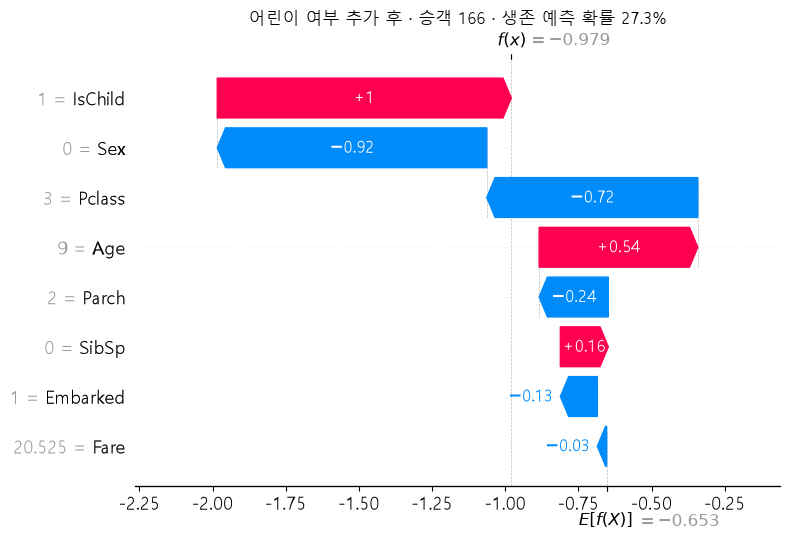

In [8]:
child_background = shap.maskers.Independent(X_train_child, max_samples=len(X_train_child))
child_explainer = shap.LinearExplainer(child_model, child_background)
shap_values_child = child_explainer(X_test_child)
shap.plots.waterfall(shap_values_child[selected_position], max_display=len(X_test_child.columns), show=False)
plt.title(f"어린이 여부 추가 후 · 승객 {selected_passenger_id} · 생존 예측 확률 {y_proba_child[selected_position]:.1%}")
plt.tight_layout()
plt.show()



어린이 여부는 생존 방향으로 기여했습니다. 성별과 객실 등급은 여전히 사망 방향으로 기여했습니다. 다시 학습하면서 기존 항목의 기여와 시작 점수도 달라졌으므로, 확률 변화 전체를 어린이 여부 하나의 기여로 설명하지 않습니다.

**이 아이의 확률은 올랐지만 오판은 해결되지 않았습니다.** 그럼 처음 관심을 둔 남성 어린이 전체와 다른 승객의 예측은 어땠을까요?

다음 표는 같은 평가 승객에 대한 변경 전후 결과입니다. 놓침·오판은 사람 수(명), 정확도·정밀도·재현율·F1은 0~1 사이 값입니다.

In [9]:
male_survivor_mask = (results["Sex"] == "male") & (y_test == 1)
child_male_mask = male_survivor_mask & (results["Age"] < child_age)
comparison = {}
for name, prediction in [("추가 전", y_pred), ("추가 후", y_pred_child)]:
    comparison[name] = {**metrics(prediction),
        f"{child_age}세 미만 남성 생존자 놓침(명)": int((child_male_mask & (prediction == 0)).sum()),
        "남성 생존자 놓침(명)": int((male_survivor_mask & (prediction == 0)).sum()),
        "전체 생존자 놓침(명)": int(((y_test == 1) & (prediction == 0)).sum()),
        "사망자를 생존으로 오판(명)": int(((y_test == 0) & (prediction == 1)).sum())}
display(pd.DataFrame(comparison).round(3))


,추가 전,추가 후
정확도,0.804,0.799
정밀도,0.793,0.789
재현율,0.667,0.652
F1,0.724,0.714
12세 미만 남성 생존자 놓침(명),4.000,4.000
남성 생존자 놓침(명),21.000,21.000
전체 생존자 놓침(명),23.000,24.000
사망자를 생존으로 오판(명),12.000,12.000


남성 어린이 생존자는 추가 전후 모두 **5명 중 4명을 놓쳤습니다.** 전체 생존자 놓침은 **23명에서 24명**으로 늘었습니다.

이번 시도는 처음 관심을 둔 그룹의 놓침을 줄이지 못했습니다. 그래도 SHAP과 예측 확률을 함께 보면서 **어린이라는 정보는 생존 쪽으로 반영됐지만 최종 분류를 바꿀 만큼은 아니었다**는 점을 확인했습니다. 한 번의 결과로 모든 어린이 구분 방법이 효과 없다고 일반화하지 않습니다.

위 수치는 기본 설정의 결과입니다. 설정이나 승객을 바꿨다면 출력으로 다시 확인하세요. 여러 방법을 비교해 선택할 때는 학습 자료 안에 검증 자료를 따로 두고, 최종 평가는 선택에 쓰지 않은 자료에서 합니다.

## 6. 직접 탐색 — 내가 궁금한 예측

앞의 `results`에서 더 알아보고 싶은 승객이나 그룹을 고르세요. 무엇이 궁금한지 자신의 말로 정하고 Continue와 대화하며 분석합니다. 위 예시의 남성 어린이를 다시 고를 필요는 없습니다.

준비된 자료는 원본 `df`, 모델 입력 `X_train`·`X_test`, 정답 `y_train`·`y_test`, 초기 모델 `model`, 예측표 `results`, 초기 기여도 `shap_values`·`shap_table`입니다. AI에는 준비 코드와 실제 결과를 함께 전달하세요.

<details><summary>막힐 때: 어디서 시작할까?</summary>

생존으로 예측했지만 실제로 사망한 승객, 판단 기준 근처의 승객, 비슷한 정보를 가졌는데 예측이 다른 승객 등이 출발점이 될 수 있습니다. 먼저 정보표와 한 사람의 SHAP을 함께 보고 질문을 좁혀보세요. 다른 질문도 가능합니다.
</details>

### 분석과 변경 — 무엇을 확인하고 왜 바꿀까?

관심 예측을 설명할 표나 그래프를 만들고, 학습 자료에서 정답과의 관계를 확인하세요. 현재 입력이 그 정보를 어떻게 담고 있는지 살펴본 뒤 변경할 한 가지를 정합니다. AI에는 자신의 생각을 먼저 전달하고 구현을 요청하세요.

<details><summary>막힐 때: 어떤 비교가 도움이 될까?</summary>

같은 실제 라벨 안에서 맞춤·틀림을 비교하면 오류의 특징을 볼 수 있습니다. 학습 자료에서 두 라벨을 모두 포함해 그룹별 인원과 생존 비율을 보면 입력과 정답의 관계를 확인할 수 있습니다. 숫자 항목은 분포나 산점도, 범주 항목은 인원·비율 표를 고려하세요. SHAP이 크다는 이유만으로 해당 항목을 삭제하지 말고 확인할 근거를 찾으세요.
</details>

### 결과 확인 — 처음 궁금했던 예측은 어떻게 달라졌나?

같은 평가 승객과 판단 기준으로 초기 모델과 비교하세요. 입력을 바꾸는 실험에서는 모델 종류를 유지하고, 데이터에서 정하는 기준은 학습 자료에서 구합니다. 실제 정답을 입력에 넣지 않습니다.

전체 지표와 **처음 선택한 같은 승객·그룹**의 결과를 함께 확인하세요. 관심 승객의 예측 확률과 SHAP을 다시 읽고, 선택한 표·그래프로 **관찰 → 변경 이유 → 실제 결과**를 짧게 설명합니다. 개선되지 않아도 무엇을 확인했는지 설명하면 됩니다.

### 참고

- [SHAP: 선형 모델 설명](https://shap.readthedocs.io/en/latest/generated/shap.LinearExplainer.html)
- [SHAP: beeswarm 읽기](https://shap.readthedocs.io/en/stable/example_notebooks/api_examples/plots/beeswarm.html)
- [SHAP: waterfall 읽기](https://shap.readthedocs.io/en/stable/example_notebooks/api_examples/plots/waterfall.html)